In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statmorph

from astropy.io import fits
from astropy.table import Table

import astrokit as ak

DIR_DATA = Path("/Users/rui/Packages/astrokit/demo/data/example_data_galfitm")

source_name = 'SDSS1420+5300A'
flt_names = ['F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F444W']

## Given the input file pathes

In [10]:
path_input_img = {}
path_input_err = {}
path_input_mask = {}
path_input_psf = {}

for flt in flt_names:
    path_input_img[flt] = DIR_DATA / 'img_sci' / f"{source_name}_{flt}.fits"
    path_input_err[flt] = DIR_DATA / 'img_err' / f"{source_name}_{flt}_err.fits"
    path_input_mask[flt] = DIR_DATA / 'img_mask' / f"{source_name}_{flt}_mask.fits"
    path_input_psf[flt] = DIR_DATA / 'img_psf' / f"{source_name}_{flt}_PSF.fits"

## Get the initial parameters

In [11]:
# background
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

bkg_dict = {}
for flt in flt_names:
    path = path_input_img[flt]
    img = fits.getdata(path)
    bkg = Background2D(
        data=img, # 原始图像
        box_size=(20, 20), # 网格尺寸
        sigma_clip=SigmaClip(sigma=3.0), # 每个网格内使用sigma截断算法计算背景
        bkg_estimator=MedianBackground(),  # 每个网格选用的背景等级估计算法
        filter_size=(3, 3) # 中值滤波器大小，用于平滑异常估计值
        )
    bkg_dict[flt] = round(float(bkg.background_median), 3)
bkg_dict

{'F115W': 4.66,
 'F150W': 3.772,
 'F200W': 4.41,
 'F277W': 28.634,
 'F356W': 52.558,
 'F444W': 72.155}

In [12]:
def get_initial_cat(flt, detect_threshold_nsigma=3, kernel_size=11, npixels=11, 
                    contrast=0.01, nlevels=32):
    img = fits.getdata(path_input_img[flt])
    img_err = fits.getdata(path_input_err[flt])

    detect_res = ak.phot.source_detect(
        img,
        detect_threshold_nsigma=detect_threshold_nsigma,
        kernel_size=kernel_size, npixels=npixels, 
        show=True, cmap='gray', 
        contrast=contrast, nlevels=nlevels,
        fig_title=f"Detection Image ({flt})",
    )
    header = fits.getheader(path_input_img[flt])
    zp = header['MAG_ZP']
    exptime = header['EXPTIME']

    segment_map = detect_res['segment_map']
    cat = detect_res['catalog']
    cat.insert(4, 'mag_segment', zp - 2.5 * np.log10(cat['segment_flux']/exptime))
    cat.insert(5, 'mag_kron', zp - 2.5 * np.log10(cat['kron_flux']/exptime))
    cat.insert(6, 'n_sersic', np.nan)
    cat.insert(7, 'PA_sersic', np.nan)
    del cat['segment_flux']
    del cat['kron_flux']

    for i, row in cat.iterrows():
        try:
            obj_morphs = statmorph.SourceMorphology(
                label=row['label'], image=img, segmap=segment_map, 
                weightmap=img_err
            )
            pa = (90.0 - np.degrees(obj_morphs.sersic_theta)) % 180.0
            n_sersic = obj_morphs.sersic_n
        except Exception as e:
            print(f"Warning: statmorph failed for object {row['label']} in {flt}: {e}")
            n_sersic = np.nan
            pa = np.nan
        cat.at[i, 'n_sersic'] = n_sersic
        cat.at[i, 'PA_sersic'] = pa

    return cat

In [13]:
cat = {}

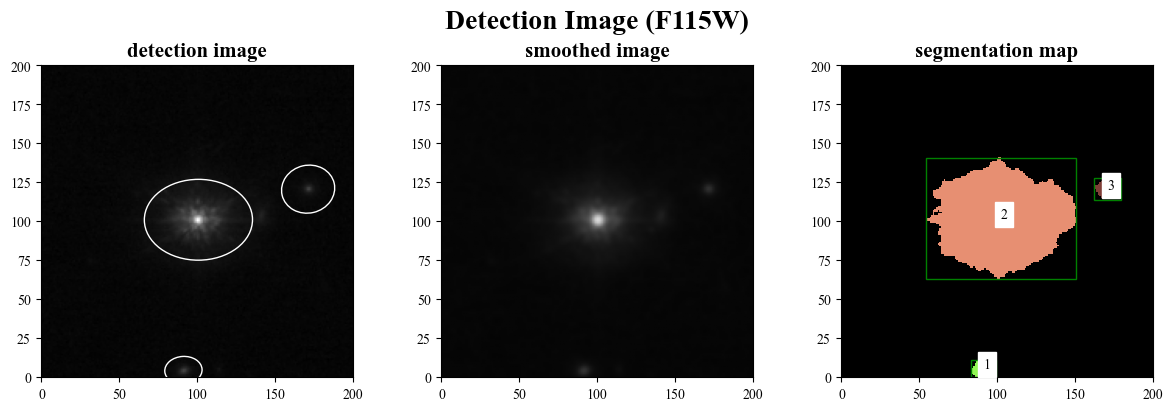

In [14]:
cat['F115W'] = get_initial_cat('F115W', detect_threshold_nsigma=7, kernel_size=25, npixels=25, contrast=0.1, nlevels=64)

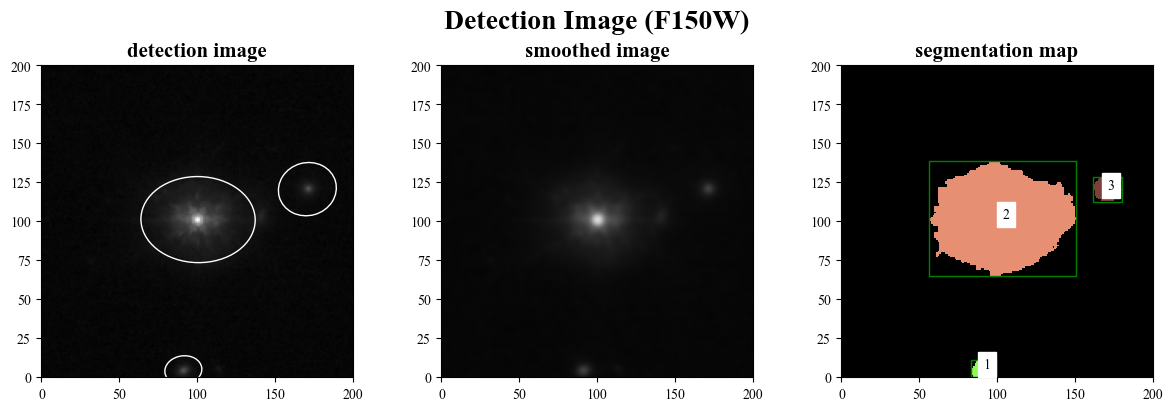

In [15]:
cat['F150W'] = get_initial_cat('F150W', detect_threshold_nsigma=7, kernel_size=25, npixels=25, contrast=0.1, nlevels=64)

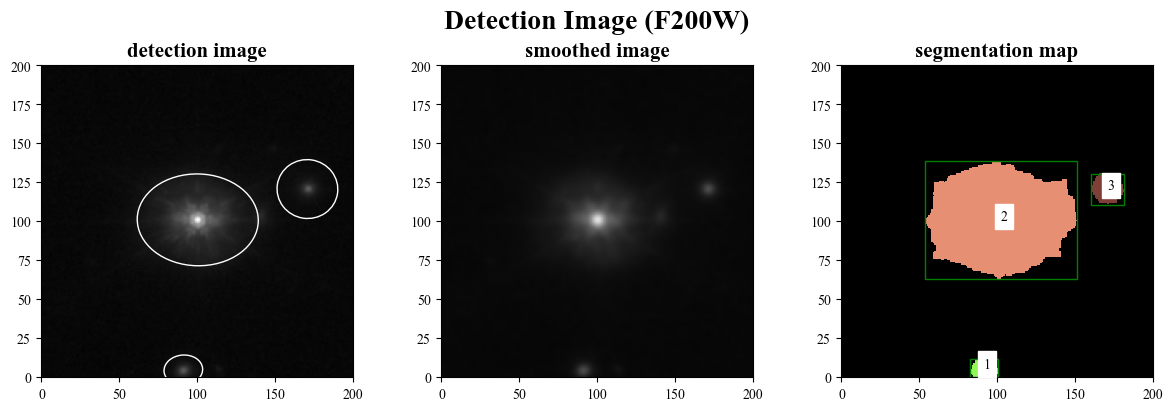

In [16]:
cat['F200W'] = get_initial_cat('F200W', detect_threshold_nsigma=7, kernel_size=25, npixels=25, contrast=0.1, nlevels=64)

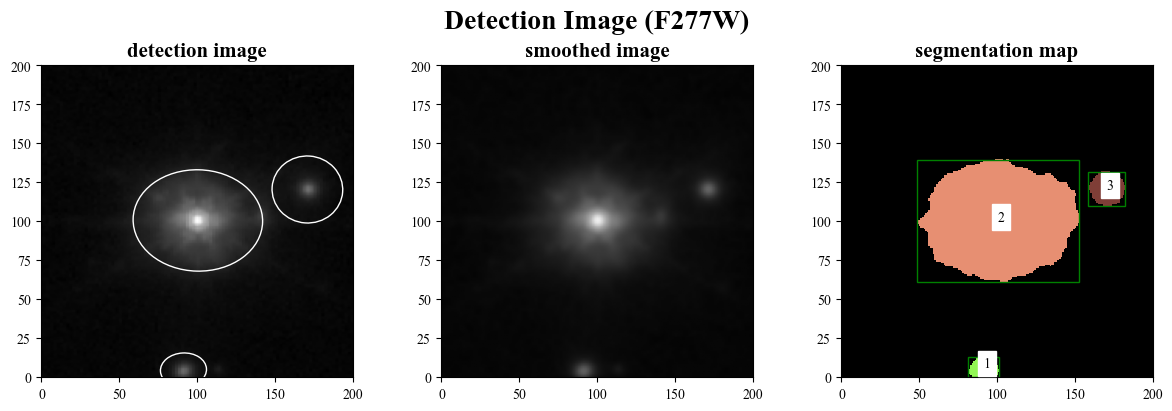

In [17]:
cat['F277W'] = get_initial_cat('F277W', detect_threshold_nsigma=7, kernel_size=25, npixels=25, contrast=0.1, nlevels=64)

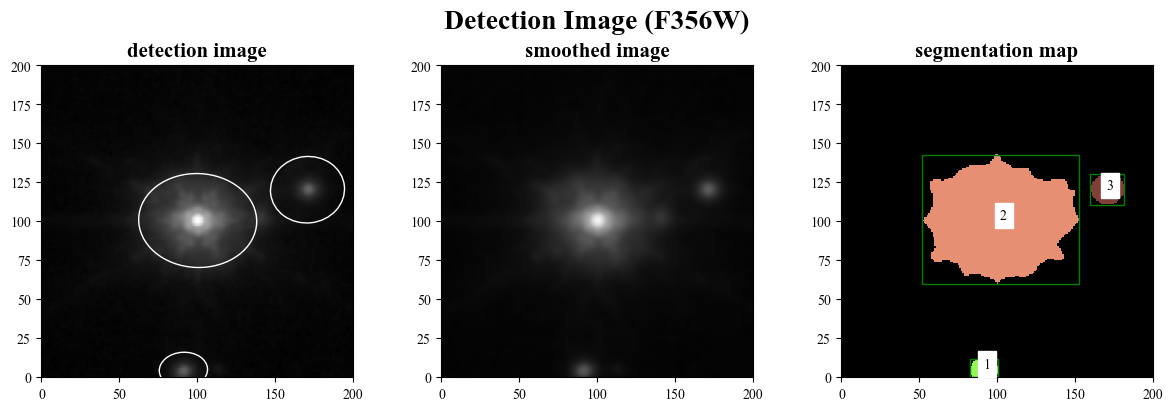

In [18]:
cat['F356W'] = get_initial_cat('F356W', detect_threshold_nsigma=7, kernel_size=25, npixels=25, contrast=0.1, nlevels=64)

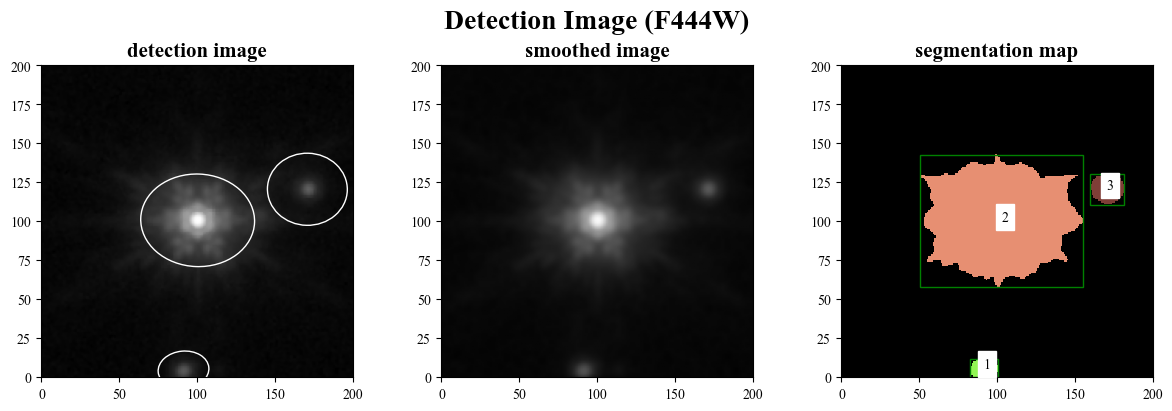

In [19]:
cat['F444W'] = get_initial_cat('F444W', detect_threshold_nsigma=7, kernel_size=25, npixels=25, contrast=0.1, nlevels=64)

In [20]:
obj1_params = pd.DataFrame({
    'F115W': cat['F115W'].iloc[1], 
    'F150W': cat['F150W'].iloc[1],
    'F200W': cat['F200W'].iloc[1], 
    'F277W': cat['F277W'].iloc[1],
    'F356W': cat['F356W'].iloc[1],
    'F444W': cat['F444W'].iloc[1]
}).T
obj1_params.loc[obj1_params['n_sersic'] > 4, 'n_sersic'] = 4
obj1_params

,class,label,x,y,mag_segment,mag_kron,n_sersic,PA_sersic,a,b,...,fwhm,gini,min_value,max_value,area,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,Dc
F115W,target,2,100.912455,100.794568,20.153706,20.21156,4,94.196349,9.937643,7.42561,...,20.656512,0.820023,23.127089,276196.414542,4776.0,55,150,63,140,0.506843
F150W,target,2,100.681571,100.901102,19.978026,20.027409,4,91.558482,10.499376,7.906292,...,21.885032,0.794033,18.067067,179130.561704,4773.0,57,150,65,138,0.440285
F200W,target,2,100.493022,100.738614,19.704757,19.748427,4,93.162369,11.123543,8.43315,...,23.243113,0.787328,26.454551,182897.35361,5290.0,54,151,63,138,0.238716
F277W,target,2,100.554414,100.352408,19.421702,19.456327,4,93.384088,11.897281,9.311052,...,25.155882,0.772886,188.716537,389642.81916,5926.0,49,152,61,139,0.157303
F356W,target,2,100.449489,100.307949,18.993389,19.037444,4,92.90638,10.845942,8.627672,...,23.076707,0.798299,381.909499,599215.790152,5594.0,52,152,60,142,0.198582
F444W,target,2,100.415343,100.4394,18.565044,18.612902,3.784111,92.950936,10.462009,8.502185,...,22.447548,0.819597,406.033688,646818.672623,5885.0,51,155,58,142,0.104111


In [21]:
obj2_params = pd.DataFrame({
    'F115W': cat['F115W'].iloc[2], 
    'F150W': cat['F150W'].iloc[2],
    'F200W': cat['F200W'].iloc[2], 
    'F277W': cat['F277W'].iloc[2],
    'F356W': cat['F356W'].iloc[2],
    'F444W': cat['F444W'].iloc[2]
}).T
obj2_params.loc[obj2_params['n_sersic'].isna(), 'n_sersic'] = obj2_params['n_sersic'].mean(skipna=True)
obj2_params

,class,label,x,y,mag_segment,mag_kron,n_sersic,PA_sersic,a,b,...,fwhm,gini,min_value,max_value,area,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,Dc
F115W,near,3,171.466269,120.478361,25.269715,24.808224,0.241115,79.816393,3.028751,2.708653,...,6.765782,0.484507,34.07857,1308.68029,177.0,163,179,114,127,73.724801
F150W,near,3,170.976286,120.490808,24.523947,24.112133,0.30505,72.98172,3.334267,3.023757,...,7.494924,0.511055,27.445549,1426.024333,234.0,162,180,113,128,73.256668
F200W,near,3,171.010751,120.544535,24.032103,23.687092,0.30055,NaN,3.61223,3.495117,...,8.369398,0.537746,39.993369,2045.956506,313.0,161,181,111,130,73.304498
F277W,near,3,170.993067,120.258061,23.638047,23.262206,0.312548,62.865457,4.088368,3.874641,...,9.379104,0.528769,215.39637,7894.610031,392.0,159,182,110,131,73.209654
F356W,near,3,171.06019,120.114035,23.531087,23.054886,0.343487,53.529169,4.06315,3.643074,...,9.086856,0.479006,369.713541,8859.347067,334.0,160,181,111,130,73.235584
F444W,near,3,170.976811,120.405627,23.414502,22.830412,0.30055,NaN,4.159491,3.753477,...,9.329064,0.444062,473.033554,8152.085149,333.0,160,181,111,130,73.233973


## Define Models

In [22]:
models = ak.wrapper.GalfitMModel()
models.add_sky(
    background=list(bkg_dict.values()), 
    fit_background=[1, 1, 1, 1, 1, 1], 
    sky_grad_x=0, fit_sky_grad_x=0, 
    sky_grad_y=0, fit_sky_grad_y=0, 
)
models.add_psf(
    x=list(round(v, 2) for v in obj1_params['x'].to_dict().values()), 
    y=list(round(v, 2) for v in obj1_params['y'].to_dict().values()),
    mag=list(round(v, 2) for v in obj1_params['mag_segment'].to_dict().values()),
)
models.add_sersic(
    x=list(round(v, 2) for v in obj1_params['x'].to_dict().values()),
    y=list(round(v, 2) for v in obj1_params['y'].to_dict().values()),
    mag=list(round(v, 2) for v in obj1_params['mag_segment'].to_dict().values()),
    re=list(round(v, 2) for v in obj1_params['re'].to_dict().values()),
    sersic_index=list(round(v, 2) for v in obj1_params['n_sersic'].to_dict().values()),
    axis_ratio=list(round(v, 2) for v in obj1_params['axis_ratio'].to_dict().values()),
    PA=list(round(v, 2) for v in obj1_params['PA'].to_dict().values())
)
models.add_sersic(
    x=list(round(v, 2) for v in obj2_params['x'].to_dict().values()),
    y=list(round(v, 2) for v in obj2_params['y'].to_dict().values()),
    mag=list(round(v, 2) for v in obj2_params['mag_segment'].to_dict().values()),
    re=list(round(v, 2) for v in obj2_params['re'].to_dict().values()),
    sersic_index=list(round(v, 2) for v in obj2_params['n_sersic'].to_dict().values()),
    axis_ratio=list(round(v, 2) for v in obj2_params['axis_ratio'].to_dict().values()),
    PA=list(round(v, 2) for v in obj2_params['PA'].to_dict().values())
)
print(models.feedme)


# Component number: 1
 0) sky                                       # object type       
 1) 4.66,3.772,4.41,28.634,52.558,72.155 band 1,1,1,1,1,1 band     # sky background [ADU counts]
 2) 0 band               0 band               # dsky/dx (sky gradient in x)
 3) 0 band               0 band               # dsky/dy (sky gradient in y) 
 z) 0                                         #  Skip this model in output image?  (yes=1, no=0)

# Component number: 2
 0) psf                                       # object type       
 1) 100.91,100.68,100.49,100.55,100.45,100.42 band 1 band               # position x [pixel]
 2) 100.79,100.9,100.74,100.35,100.31,100.44 band 1 band               # position y [pixel]
 3) 20.15,19.98,19.7,19.42,18.99,18.57 band 1 band               # total magnitude   
 z) 0                                         #  Skip this model in output image?  (yes=1, no=0)

# Component number: 3
 0) sersic                                    # Object type       
 1) 100.91,100.

## Define Galfitm Task

In [23]:
source_name = 'SDSS1420+5300A'

galfitm = ak.wrapper.GalfitM(
    task_name=source_name, 
    dir_output=DIR_DATA / 'output', 
    path_list_input_img=list(path_input_img.values()), 
    path_list_input_sigma=list(path_input_err.values()),
    path_list_input_psf=list(path_input_psf.values()),
    path_list_input_mask=list(path_input_mask.values())
)

## Define Constraints

In [24]:
galfitm.new_constrains()
galfitm.add_constrains(component=3, parameter='n', constraint='0.3 to 7')
galfitm.add_constrains(component=3, parameter='re', constraint='1 to 100')
galfitm.add_constrains(component=3, parameter='q', constraint='0.1 to 1')
galfitm.add_constrains(component=3, parameter='pa', constraint='-179.99 to 180')
galfitm.add_constrains(component=2, parameter='x', constraint='-5 5')
galfitm.add_constrains(component=2, parameter='y', constraint='-5 5')
galfitm.add_constrains(component=2, parameter='mag', constraint='10 to 30')
galfitm.add_constrains(component=2, parameter='mag', constraint='10 to 30')
galfitm.add_constrains(component='2_3', parameter='x_0', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='x_1', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='x_2', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='x_3', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='x_4', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='x_5', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='x_6', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_0', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_1', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_2', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_3', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_4', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_5', constraint='offset')
galfitm.add_constrains(component='2_3', parameter='y_6', constraint='offset')
galfitm.add_constrains(component=4, parameter='x', constraint='-5 5')
galfitm.add_constrains(component=4, parameter='y', constraint='-5 5')
galfitm.add_constrains(component=4, parameter='n', constraint='0.3 to 7')
galfitm.add_constrains(component=4, parameter='re', constraint='1 to 100')
galfitm.add_constrains(component=4, parameter='pa', constraint='-179.99 to 180')
galfitm.add_constrains(component=4, parameter='q', constraint='0.1 to 1')
galfitm.add_constrains(component=4, parameter='mag', constraint='10 to 30')

## Config

In [25]:
galfitm.config(
    models=models, 
    use_constraints=True,
    band_labels=['F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F444W'],
    band_wavelengths=[1.154, 1.501, 1.990, 2.786, 3.563, 4.421], 
    fit_region=[1, 201, 1, 201], 
    mag_zeropoint=[26.907, 27.205, 27.394, 28.859, 29.069, 29.102], 
    pixel_scale=0.030, 
    non_parameter_components=[0, 0.75, 25, 4, 40, 0.00, 1.00], 
    multinest_options=[0, 0, 50, 0.8, 0.5, 100000]
)

## Run Galfitm

In [26]:
# galfitm.run(run_in_terminal=True, silent=True)

## Show Results

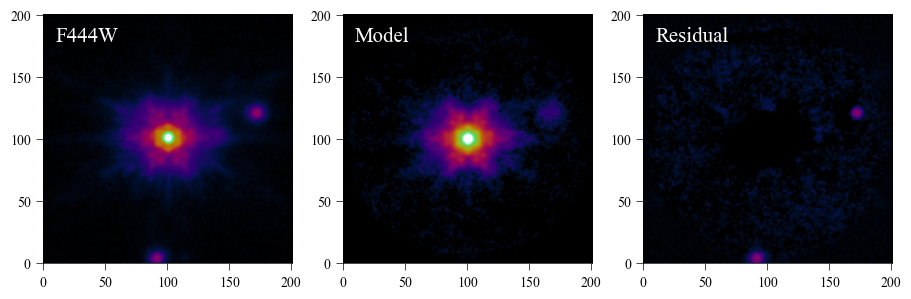

In [27]:
fig = galfitm.plot("F444W")

In [33]:
galfitm.get_res()

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                  201 / Length of data axis 1                          
NAXIS2  =                  201 / Length of data axis 2                          
PCOUNT  =                    0 / number of random group parameters              
GCOUNT  =                    1 / number of random groups                        
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =              26327.5 / Pixel coordinate of reference point            
CRPIX2  =              -3364.5 / Pixel coordinate of reference point            
PC1_1   =    -0.64678977951046 / Coordinate transformation matrix element       
PC1_2   =    -0.76266832969569 / Coordinate transformation matrix element       
PC2_1   =    -0.762668329695